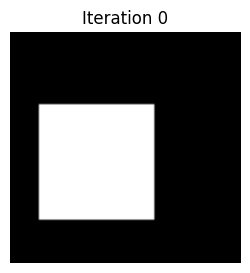

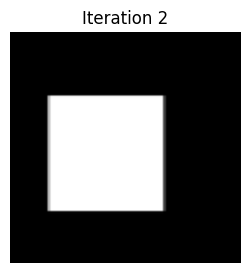

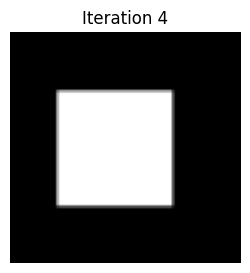

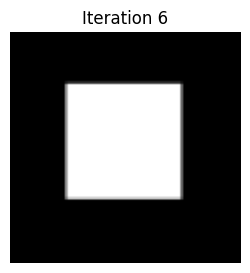

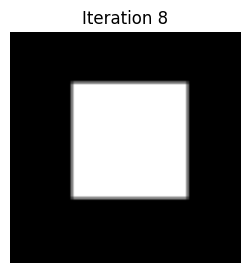

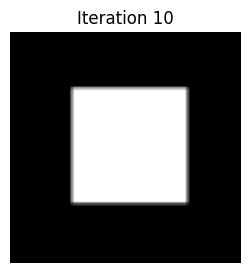

Estimated translation: tensor([ 0.2789, -0.1124])


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# synthetic target image (white square)
target = torch.zeros(1, 1, 80, 80)
target[:, :, 20:60, 20:60] = 1.0

# initial “moving” image: shifted version
moving = torch.zeros_like(target)
moving[:, :, 25:65, 10:50] = 1.0

# parameters to learn: translation tx, ty
theta = torch.tensor([0.0, 0.0], requires_grad=True)
optimizer = torch.optim.Adam([theta], lr=0.05)

def warp_image(img, tx, ty):
    B, C, H, W = img.shape
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, H),
        torch.linspace(-1, 1, W),
        indexing="ij"
    )
    grid = torch.stack([grid_x - tx, grid_y - ty], dim=-1)
    return F.grid_sample(img, grid.unsqueeze(0), mode="bilinear", align_corners=True)

for it in range(11):
    optimizer.zero_grad()
    warped = warp_image(moving, theta[0], theta[1])
    loss = F.mse_loss(warped, target)
    loss.backward()
    optimizer.step()

    if it % 2 == 0:
        plt.figure(figsize=(3,3))
        plt.title(f"Iteration {it}")
        plt.imshow(warped[0,0].detach(), cmap='gray')
        plt.axis('off')
        plt.show()

print("Estimated translation:", theta.detach())
